In [46]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df_population_raw = pd.read_csv(r"C:\Users\AK\Downloads\population_total.csv")

In [3]:
df_population_raw

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09
...,...,...,...
4180,United States,1965.0,1.997337e+08
4181,United States,1960.0,1.867206e+08
4182,United States,1955.0,1.716853e+08
4183,India,1960.0,4.505477e+08


# 1 making a pivot table 
.pivot(): returns reshaped dataframe organized by given index / column value (" pivot without aggregation ")

In [4]:
# dropping null values 
df_population_raw.dropna(inplace=True)

In [5]:
# making a pivot table 
df_pivot = df_population_raw.pivot(index="year",
                       columns="country",
                       values="population")

In [6]:
# select some countries
df_pivot = df_pivot[["United States", "India", "China", "Indonesia", "Brazil"]]


In [7]:
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


# 2 Lineplot

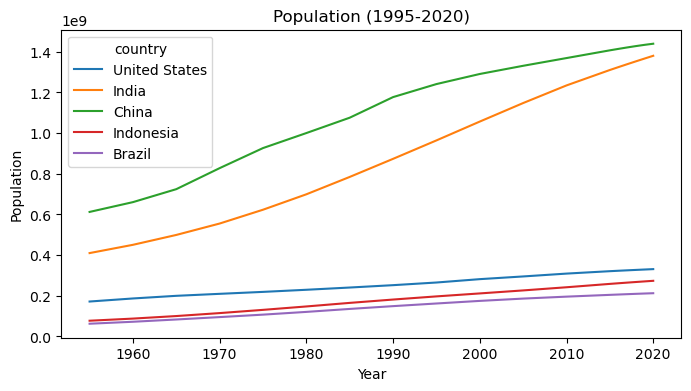

In [49]:
df_pivot.plot(kind="line", xlabel="Year", ylabel="Population", title="Population (1995-2020)", 
             figsize=(8,4))

# save plot 
plt.savefig("my_test.png")
# show plot 
plt.show()

In [50]:
df_pivot.to_excel("pivot_table.xlsx")

# 3 Barplot
single Barplot

In [9]:
# selecting only one year (2020)
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])]

In [10]:
df_pivot_2020

country,United States,India,China,Indonesia,Brazil
year,,,,,
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


In [11]:
# transfer dataframe from rows to columns or vicevers 
df_pivot_2020 = df_pivot_2020.T

<Axes: title={'center': 'Population of 2020'}, xlabel='Year', ylabel='Population'>

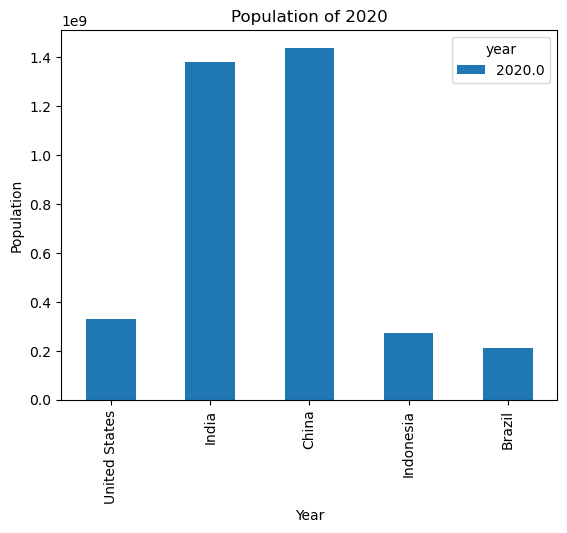

In [12]:
# making Barplot
df_pivot_2020.plot(kind="bar",
                  xlabel="Year",
                  ylabel="Population",
                  title="Population of 2020")

# Barplot grouped by "n" variables 

In [13]:
# selecing a few year 
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])]

<Axes: xlabel='Years', ylabel='population'>

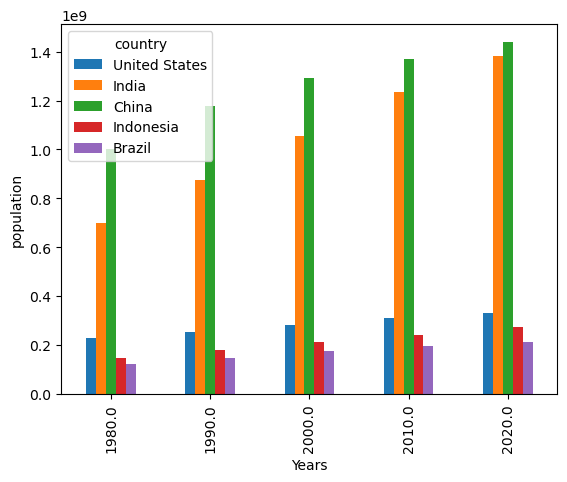

In [14]:
# making grouped barplot 
df_pivot_sample.plot(kind="bar", 
                    ylabel="population", 
                    xlabel="Years")

# 4 Piechart 

In [16]:
# changing column name 
df_pivot_2020 = df_pivot_2020.rename(columns={2020:"2020"})


<Axes: title={'center': 'Populaton in 2020(%)'}, ylabel='2020'>

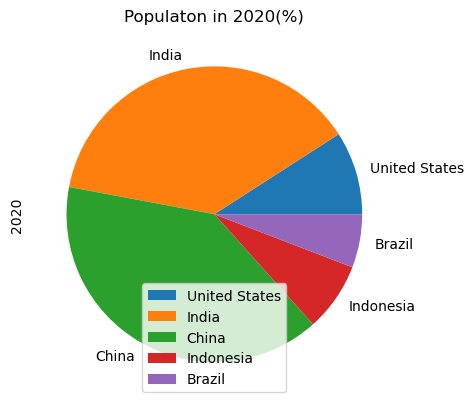

In [19]:
# making the plot 
df_pivot_2020.plot(kind="pie",
                   y="2020",
                  title="Populaton in 2020(%)")

# 5 Boxplot

single boxplot

<Axes: ylabel='Population'>

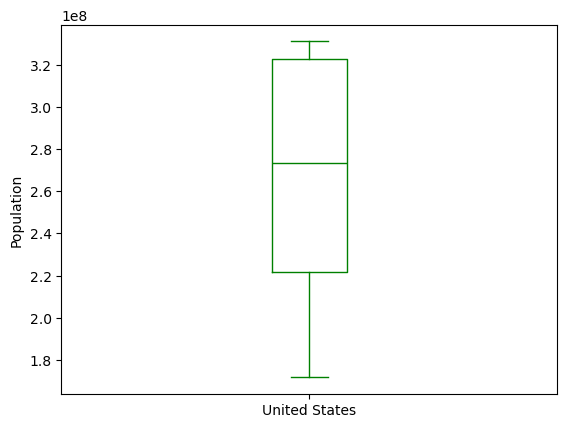

In [23]:
df_pivot["United States"].plot(kind="box",
                              color="green", 
                              ylabel="Population")

<Axes: >

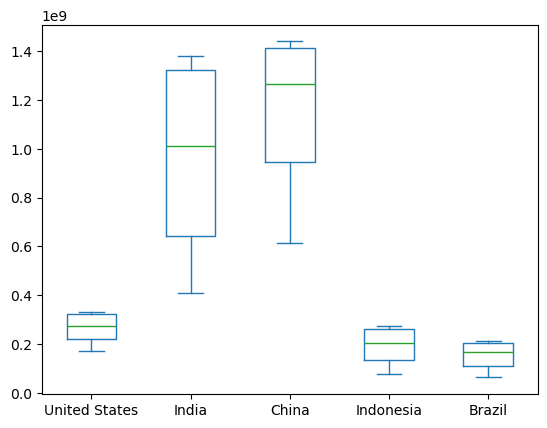

In [25]:
# multiple Boxplot
df_pivot.plot(kind="box")

# 5 Histogram

<Axes: ylabel='Frequency'>

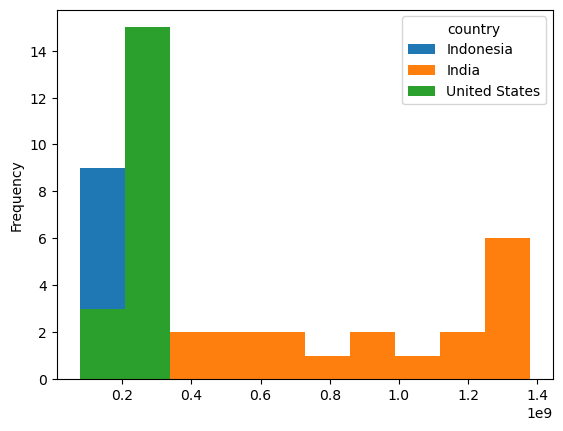

In [34]:
df_pivot[["Indonesia", "India", "United States"]].plot(kind="hist")

# 7 ScatterPlot

In [38]:
# selecting a sample of the raw data 
df_sample = df_population_raw[df_population_raw["country"].isin(["Indonesia", "India", "United States", "chaina", "Brazil"])]

<Axes: xlabel='year', ylabel='population'>

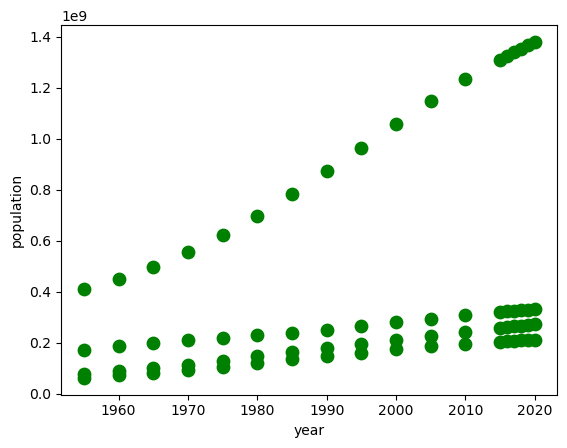

In [45]:
# creating the plot 
df_sample.plot(kind="scatter", 
              x="year",
              y="population", 
              s=80,
              color="green")